In [1]:
from pathlib import Path

SEG_EVAL_DIR = Path("C:\\Users\\juhe9\\repos\\MasterThesis\\ForkSight\\Data\\evaluation_output\\segmentation\\20260321_115408")
JD_EVAL_DIR = Path("C:\\Users\\juhe9\\repos\\MasterThesis\\ForkSight\\Data\\evaluation_output\\junction_detection\\20260327_163657")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

In [3]:
def bold_best(df: pd.DataFrame, lower_is_better_cols: set[str] | None = None):
    """Return a Styler that bolds the best value in each column."""
    lower_is_better_cols = lower_is_better_cols or set()

    def _apply(s: pd.Series) -> list[str]:
        numeric = pd.to_numeric(s, errors="coerce")
        want_min = s.name in lower_is_better_cols
        best = numeric.min() if want_min else numeric.max()
        return [
            "font-weight: bold" if (not np.isnan(v) and v == best) else ""
            for v in numeric
        ]

    float_cols = df.select_dtypes(include="number").columns
    fmt = {c: "{:.4f}" for c in float_cols}
    return (
        df.style
        .apply(_apply, axis=0)
        .format(fmt, na_rep="–")
        .set_table_styles([{"selector": "th, td", "props": "font-family: inherit; font-size: inherit;"}])
    )


def horizontal_bar_groups(df: pd.DataFrame, col_groups: list[tuple],
                          lower_is_better: set[str] | None = None,
                          col_rename: dict | None = None,
                          ylim: tuple | None = (0, 1.18),
                          cols_per_row: int | None = None,
                          suptitle: str = "") -> None:
    """Bar chart grid, one subplot per column group.  Legend is placed above the figure.

    Parameters
    ----------
    ylim         : (ymin, ymax) or None to auto-scale each subplot independently.
    cols_per_row : max subplots per row; None keeps all groups in a single row.
    """
    from matplotlib.gridspec import GridSpec

    lower_is_better = lower_is_better or set()
    col_rename = col_rename or {}

    filtered_groups = [
        [c for c in group if c in df.columns]
        for group in col_groups
    ]
    filtered_groups = [g for g in filtered_groups if g]
    if not filtered_groups:
        print("  (no columns available for bar chart)")
        return

    model_labels = [str(n) for n in df.index]
    total_cols = sum(len(g) for g in filtered_groups)
    colors = plt.cm.tab10(np.linspace(0, 0.9, len(df)))

    # Split groups into rows
    cpr = cols_per_row or len(filtered_groups)
    row_chunks = [filtered_groups[i:i + cpr]
                  for i in range(0, len(filtered_groups), cpr)]
    n_rows = len(row_chunks)

    ncol = min(len(df), 4)
    n_legend_rows = (len(df) + ncol - 1) // ncol
    top_gap = 0.05 * n_legend_rows + (0.07 if suptitle else 0.03)
    subplot_top = 1.0 - top_gap

    row_height = max(4, len(df) * 0.5 + 1.5)
    fig_width = max(10, 2.0 * total_cols)
    fig_height = row_height * n_rows

    fig = plt.figure(figsize=(fig_width, fig_height))
    outer_gs = GridSpec(n_rows, 1, figure=fig, hspace=0.45)

    first_handles, first_labels = None, None

    for row_idx, chunk in enumerate(row_chunks):
        width_ratios = [len(g) for g in chunk]
        inner_gs = outer_gs[row_idx].subgridspec(
            1, len(chunk), width_ratios=width_ratios, wspace=0.3)

        for ci, cols in enumerate(chunk):
            ax = fig.add_subplot(inner_gs[0, ci])
            x = np.arange(len(cols))
            width = 0.8 / max(len(df), 1)

            bars_by_col: dict[int, list[tuple]] = {k: [] for k in range(len(cols))}

            for i, (model, row) in enumerate(df.iterrows()):
                vals = [float(row.get(c, np.nan)) for c in cols]
                offset = (i - len(df) / 2 + 0.5) * width
                rects = ax.bar(x + offset, vals, width * 0.9,
                               label=model_labels[i], color=colors[i])
                for k, (rect, val) in enumerate(zip(rects, vals)):
                    bars_by_col[k].append((val, rect))

            if first_handles is None:
                first_handles, first_labels = ax.get_legend_handles_labels()

            # Annotation offset relative to data range
            all_vals = [v for entries in bars_by_col.values()
                        for v, _ in entries if not np.isnan(v)]
            y_range = (max(all_vals) - min(all_vals)) if len(all_vals) >= 2 else 1.0
            ann_offset = y_range * 0.025

            for k, col in enumerate(cols):
                entries = [(v, r) for v, r in bars_by_col[k] if not np.isnan(v)]
                if not entries:
                    continue
                want_min = col in lower_is_better
                best_val, best_rect = (min(entries, key=lambda t: t[0]) if want_min
                                       else max(entries, key=lambda t: t[0]))
                bar_x = best_rect.get_x() + best_rect.get_width() / 2
                ax.text(bar_x, best_rect.get_height() + ann_offset,
                        f"{best_val:.3f}",
                        ha="center", va="bottom", fontsize=7, fontweight="bold")

            tick_labels = [col_rename.get(c, c).replace(" ", "\n") for c in cols]
            ax.set_xticks(x)
            ax.set_xticklabels(tick_labels, fontsize=8)
            ax.grid(axis="y", linestyle="--", alpha=0.4)

            if ylim is not None:
                ax.set_ylim(*ylim)
            else:
                if all_vals:
                    ax.set_ylim(0, max(all_vals) + y_range * 0.15)

    plt.tight_layout(rect=[0, 0, 1, subplot_top])
    fig.legend(
        first_handles, first_labels,
        loc="lower center",
        bbox_to_anchor=(0.5, subplot_top),
        ncol=ncol,
        fontsize=8,
        framealpha=0.8,
    )
    if suptitle:
        fig.suptitle(suptitle, fontsize=12, y=0.99)

    plt.show()
    plt.close()

In [4]:
# Load segmentation metrics
_seg_csv = SEG_EVAL_DIR / "csv" / "metrics.csv"
if _seg_csv is None:
    raise FileNotFoundError(
        f"metrics.csv not found in {SEG_EVAL_DIR} or {SEG_EVAL_DIR / 'csv'}")

df_seg = pd.read_csv(_seg_csv, index_col=0)
df_seg.index.name = "Model"
print(f"Loaded segmentation metrics: {len(df_seg)} model(s) from {_seg_csv}")
df_seg.index = df_seg.index.map(str)  # ensure string index

# Optional: persistence distances
_dist_csv = SEG_EVAL_DIR / "csv" / "persistence_distances.csv"
df_dist = pd.read_csv(_dist_csv) if _dist_csv else pd.DataFrame()
if not df_dist.empty:
    print(f"Loaded persistence distances: {len(df_dist)} row(s)")

Loaded segmentation metrics: 8 model(s) from C:\Users\juhe9\repos\MasterThesis\ForkSight\Data\evaluation_output\segmentation\20260321_115408\csv\metrics.csv
Loaded persistence distances: 552 row(s)


### Segmentation Metrics — Raw

In [5]:
SEG_RAW_COLS = ["Dice", "IoU", "clDice", "tprec", "tsens"]

_raw_cols = [c for c in SEG_RAW_COLS if c in df_seg.columns]
if _raw_cols:
    display(bold_best(df_seg[_raw_cols],))
else:
    print("No raw segmentation columns found.")

,Dice,IoU,clDice,tprec,tsens
Model,,,,,
sweep-skeleton-recall-lora-BEST,0.8770,0.7826,0.9728,0.9601,0.9882
sweep-skeleton-recall-n-blocks-BEST,0.8759,0.7810,0.9731,0.9663,0.9817
sweep-clDice-n-blocks-BEST,0.8682,0.7686,0.9760,0.9734,0.9798
sweep-cldice-lora-BEST,0.8668,0.7664,0.9773,0.9746,0.9811
sweep-skeleton-recall-BEST,0.8546,0.7474,0.9478,0.9293,0.9685
sweep-cldice-BEST,0.8435,0.7313,0.9576,0.9619,0.9554
nnunet/Dataset001_Segmentation_v1/nnUNetTrainerWandb,0.8907,0.8057,0.9815,0.9811,0.9825
nnunet/Dataset001_Segmentation_v1/nnUNetTrainerClDiceLoss,0.8910,0.8061,0.9825,0.9833,0.9822


### Segmentation Metrics — Post-processed

In [6]:
SEG_PP_COLS = [
    "Dice Postprocessed", "IoU Postprocessed", "clDice Postprocessed",
    "tprec Postprocessed", "tsens Postprocessed",
]

_pp_cols = [c for c in SEG_PP_COLS if c in df_seg.columns]
if _pp_cols:
    display(bold_best(df_seg[_pp_cols]))
else:
    print("No post-processed segmentation columns found.")

,Dice Postprocessed,IoU Postprocessed,clDice Postprocessed,tprec Postprocessed,tsens Postprocessed
Model,,,,,
sweep-skeleton-recall-lora-BEST,0.8771,0.7827,0.9732,0.9610,0.9881
sweep-skeleton-recall-n-blocks-BEST,0.8761,0.7812,0.9740,0.9680,0.9816
sweep-clDice-n-blocks-BEST,0.8683,0.7687,0.9764,0.9744,0.9797
sweep-cldice-lora-BEST,0.8669,0.7665,0.9775,0.9751,0.9810
sweep-skeleton-recall-BEST,0.8555,0.7487,0.9529,0.9394,0.9678
sweep-cldice-BEST,0.8439,0.7318,0.9593,0.9657,0.9548
nnunet/Dataset001_Segmentation_v1/nnUNetTrainerWandb,0.8907,0.8057,0.9816,0.9816,0.9824
nnunet/Dataset001_Segmentation_v1/nnUNetTrainerClDiceLoss,0.8910,0.8062,0.9827,0.9838,0.9821


### Segmentation Metrics — Topological (Persistence Distances)

Lower is better for all distance metrics.

In [7]:
SEG_TOPO_COLS = [
    "Wasserstein B0 Raw", "Bottleneck B0 Raw",
    "Wasserstein B1 Raw", "Bottleneck B1 Raw",
    "Wasserstein B0 SDT", "Bottleneck B0 SDT",
    "Wasserstein B1 SDT", "Bottleneck B1 SDT",
]

_topo_cols = [c for c in SEG_TOPO_COLS if c in df_seg.columns]
if _topo_cols:
    display(bold_best(df_seg[_topo_cols], lower_is_better_cols=set(_topo_cols)))
else:
    print("No topological metric columns found.")

,Wasserstein B0 Raw,Bottleneck B0 Raw,Wasserstein B1 Raw,Bottleneck B1 Raw,Wasserstein B0 SDT,Bottleneck B0 SDT,Wasserstein B1 SDT,Bottleneck B1 SDT
Model,,,,,,,,
sweep-skeleton-recall-lora-BEST,1.3809,0.3392,0.1879,0.0940,140.1498,34.1256,44.4584,9.5100
sweep-skeleton-recall-n-blocks-BEST,1.9722,0.3241,0.2620,0.1225,121.3922,29.8662,44.0119,10.3242
sweep-clDice-n-blocks-BEST,1.4427,0.3593,0.1884,0.0947,136.5918,32.9381,49.3589,10.3841
sweep-cldice-lora-BEST,0.8152,0.2831,0.1464,0.0936,123.9356,30.8161,41.0637,9.1553
sweep-skeleton-recall-BEST,12.6706,0.4612,0.9011,0.1798,406.4885,58.3922,105.3669,18.9693
sweep-cldice-BEST,5.9364,0.4679,0.3613,0.1544,315.4159,49.2827,82.6972,16.8720
nnunet/Dataset001_Segmentation_v1/nnUNetTrainerWandb,1.0522,0.3526,0.2138,0.0983,116.5284,32.2023,37.0563,7.6317
nnunet/Dataset001_Segmentation_v1/nnUNetTrainerClDiceLoss,0.9466,0.3227,0.1343,0.0692,110.3106,29.2039,39.2097,8.9772


### Segmentation Bar Charts

C:\Users\juhe9\AppData\Local\Temp\ipykernel_29064\2911670338.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, subplot_top])


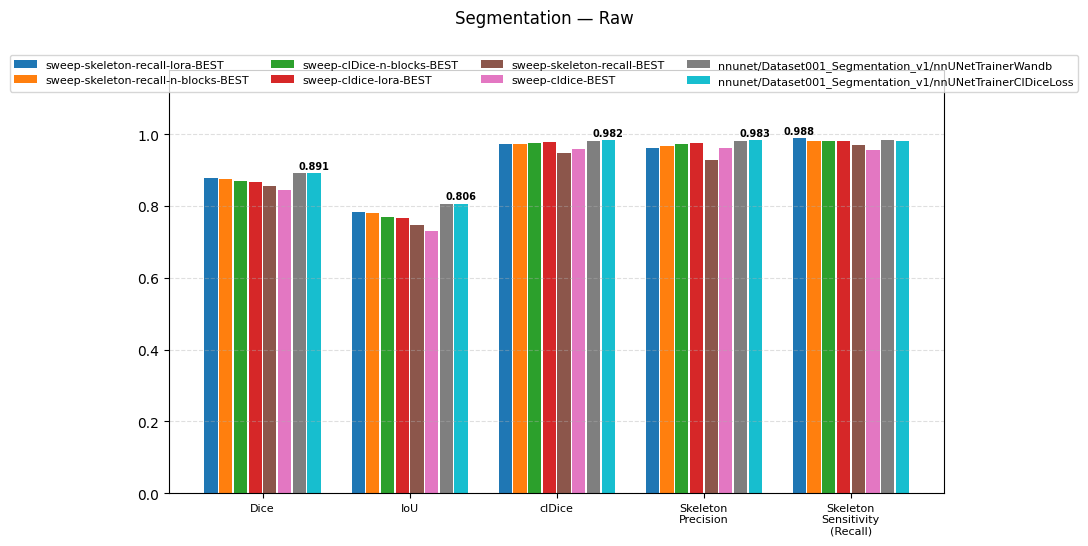

C:\Users\juhe9\AppData\Local\Temp\ipykernel_29064\2911670338.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, subplot_top])


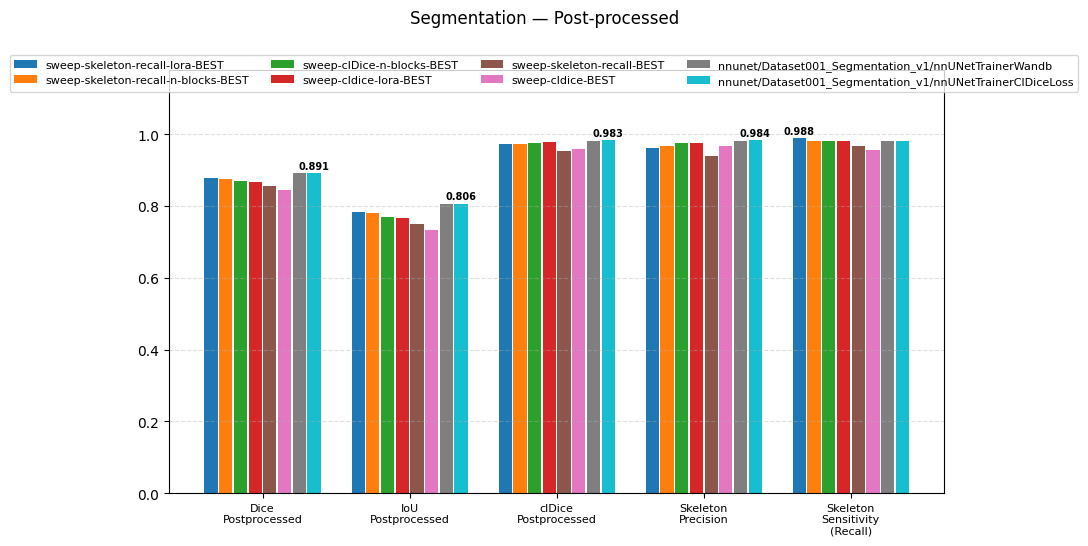

In [8]:
_SEG_RENAME = {
    "tprec": "Skeleton\nPrecision",
    "tsens": "Skeleton Sensitivity\n(Recall)",
    "tprec Postprocessed": "Skeleton\nPrecision",
    "tsens Postprocessed": "Skeleton Sensitivity\n(Recall)",
}

horizontal_bar_groups(
    df_seg,
    col_groups=[("Dice", "IoU", "clDice", "tprec", "tsens")],
    col_rename=_SEG_RENAME,
    suptitle="Segmentation — Raw",
)

horizontal_bar_groups(
    df_seg,
    col_groups=[("Dice Postprocessed", "IoU Postprocessed", "clDice Postprocessed",
                 "tprec Postprocessed", "tsens Postprocessed")],
    col_rename=_SEG_RENAME,
    suptitle="Segmentation — Post-processed",
)

C:\Users\juhe9\AppData\Local\Temp\ipykernel_29064\2911670338.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, subplot_top])


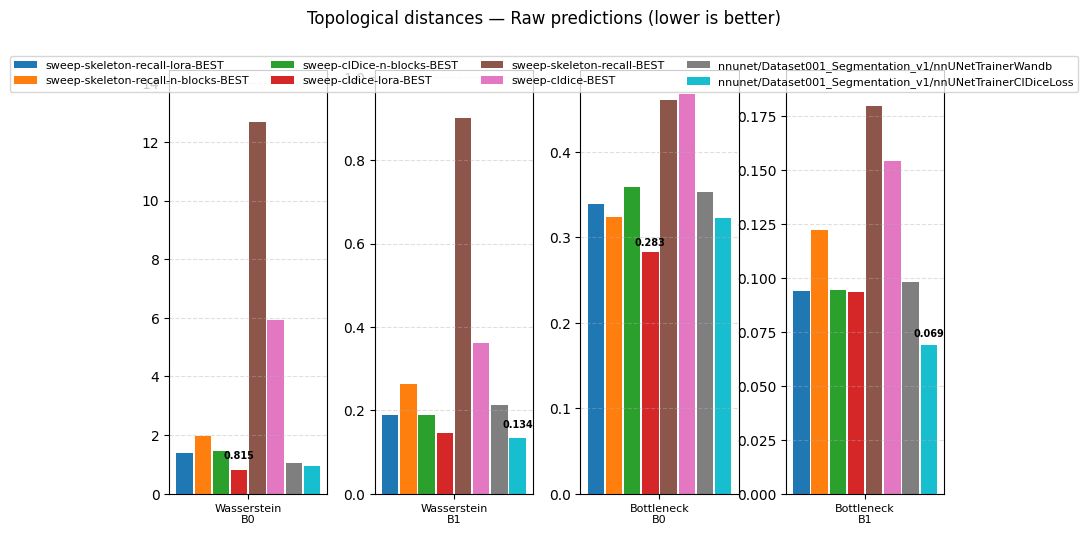

C:\Users\juhe9\AppData\Local\Temp\ipykernel_29064\2911670338.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, subplot_top])


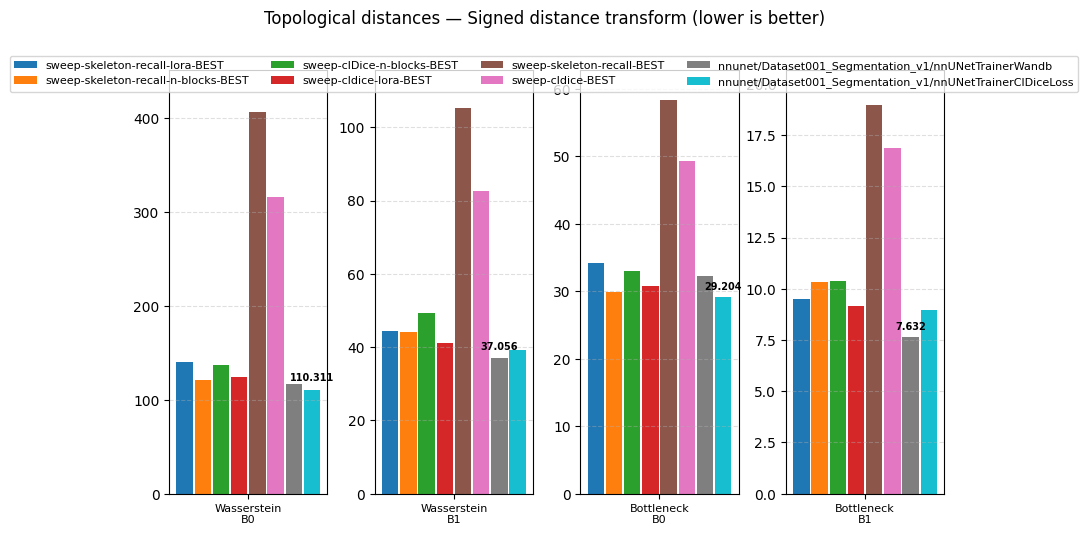

In [9]:
_TOPO_LOWER = set(SEG_TOPO_COLS)  # all distance metrics: lower is better

for _suffix, _label in [("Raw", "Raw predictions"), ("SDT", "Signed distance transform")]:
    horizontal_bar_groups(
        df_seg,
        col_groups=[
            (f"Wasserstein B0 {_suffix}",),
            (f"Wasserstein B1 {_suffix}",),
            (f"Bottleneck B0 {_suffix}",),
            (f"Bottleneck B1 {_suffix}",),
        ],
        lower_is_better=_TOPO_LOWER,
        col_rename={
            f"Wasserstein B0 {_suffix}": "Wasserstein\nB0",
            f"Wasserstein B1 {_suffix}": "Wasserstein\nB1",
            f"Bottleneck B0 {_suffix}":  "Bottleneck\nB0",
            f"Bottleneck B1 {_suffix}":  "Bottleneck\nB1",
        },
        ylim=None,
        suptitle=f"Topological distances — {_label} (lower is better)",
    )

### Persistence Diagrams

Birth–death scatter plots from the raw and SDT persistence CSVs.

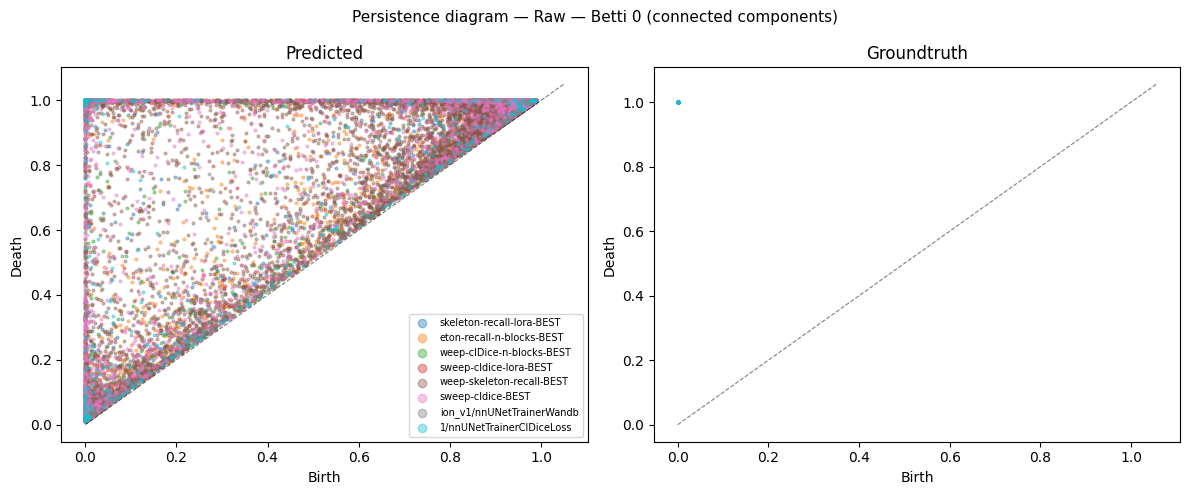

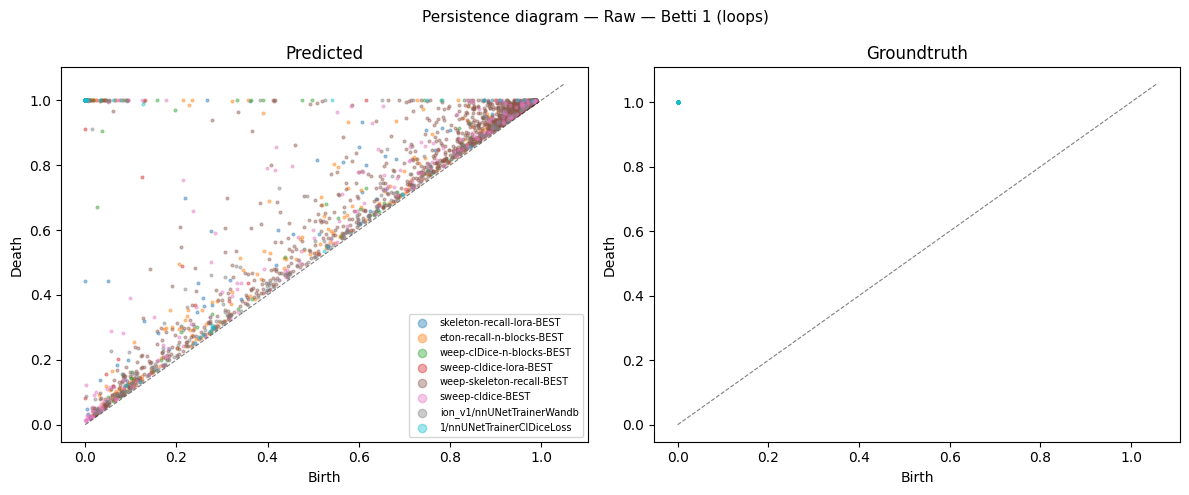

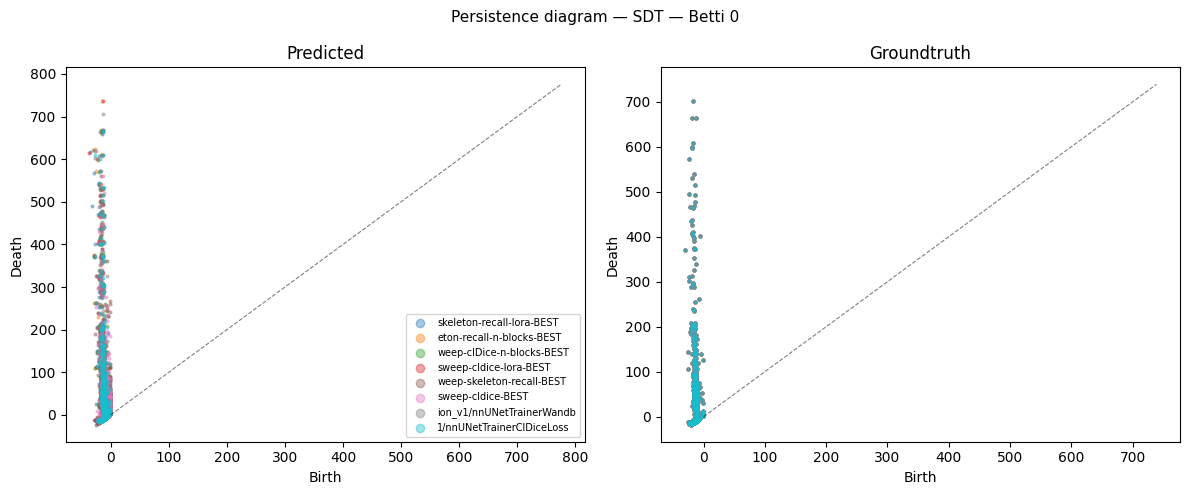

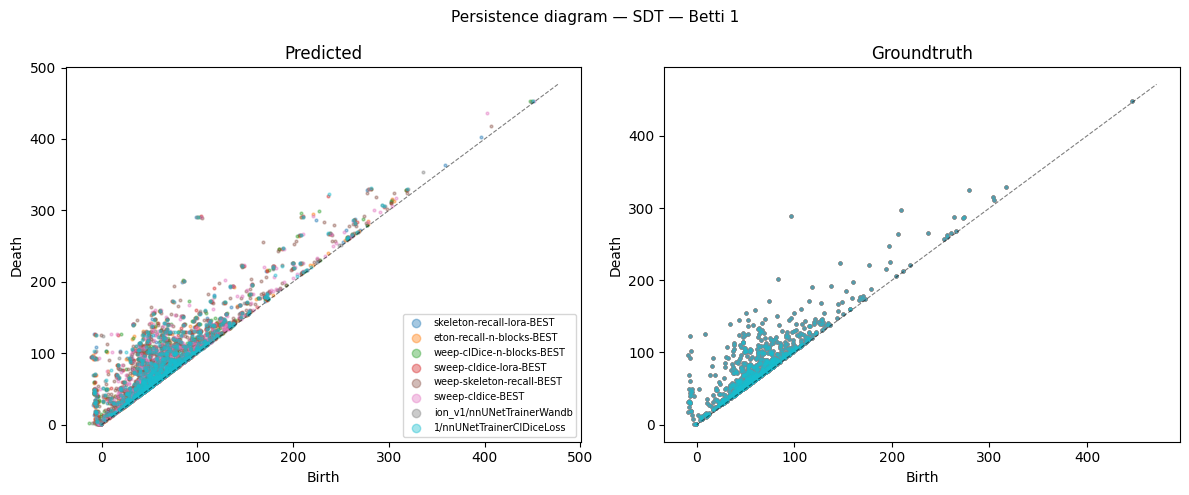

In [10]:
for filename, title in [
    ("persistence_raw_b0.csv", "Raw — Betti 0 (connected components)"),
    ("persistence_raw_b1.csv", "Raw — Betti 1 (loops)"),
    ("persistence_sdt_b0.csv", "SDT — Betti 0"),
    ("persistence_sdt_b1.csv", "SDT — Betti 1"),
]:
    _csv = SEG_EVAL_DIR / "csv" / filename
    if _csv is None:
        print(f"  {filename} not found, skipping.")
        continue

    df_pd = pd.read_csv(_csv)
    models = df_pd["model"].unique() if "model" in df_pd.columns else []
    if len(models) == 0:
        print(f"  {filename}: no model column, skipping.")
        continue

    colors = plt.cm.tab10(np.linspace(0, 0.9, len(models)))
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for ax, ptype in zip(axes, ["predicted", "groundtruth"]):
        df_sub = df_pd[df_pd["type"] ==
                       ptype] if "type" in df_pd.columns else df_pd
        for i, model in enumerate(models):
            df_m = df_sub[df_sub["model"] ==
                          model] if "model" in df_sub.columns else df_sub
            if df_m.empty:
                continue
            b, d = df_m["birth"], df_m["death"]
            ax.scatter(b, d, s=4, alpha=0.4, color=colors[i],
                       label=str(model)[-25:])
        # Diagonal (birth = death)
        lim = max(ax.get_xlim()[1], ax.get_ylim()[1])
        ax.plot([0, lim], [0, lim], "k--", linewidth=0.8, alpha=0.5)
        ax.set_xlabel("Birth")
        ax.set_ylabel("Death")
        ax.set_title(ptype.capitalize())
        if ptype == "predicted":
            ax.legend(markerscale=3, fontsize=7, loc="lower right")

    fig.suptitle(f"Persistence diagram — {title}", fontsize=11)
    plt.tight_layout()
    plt.show()
    plt.close()

---
## Junction Detection Evaluation

In [11]:
# ── Load junction detection metrics ────────────────────────────────────────
_jd_csv = JD_EVAL_DIR / "metrics.csv"
if _jd_csv is None:
    raise FileNotFoundError(
        f"metrics.csv not found in {JD_EVAL_DIR} or {JD_EVAL_DIR / 'csv'}")

df_jd = pd.read_csv(_jd_csv, index_col="model")
print(
    f"Loaded junction detection metrics: {len(df_jd)} model(s) from {_jd_csv}")
df_jd.index = df_jd.index.map(str)

Loaded junction detection metrics: 8 model(s) from C:\Users\juhe9\repos\MasterThesis\ForkSight\Data\evaluation_output\junction_detection\20260327_163657\metrics.csv


In [12]:
# Column groups — all higher-is-better
_JD_LOCALISATION = ["precision_loc", "recall_loc", "f1_loc"]
_JD_TYPE_OVERALL = ["type_accuracy"]
_JD_DETECTION_RECALL = ["detection_recall_3way", "detection_recall_4way"]
_JD_TYPE_3WAY = ["type_precision_3way", "type_recall_3way", "type_f1_3way"]
_JD_TYPE_4WAY = ["type_precision_4way", "type_recall_4way", "type_f1_4way"]

_JD_DISPLAY_COLS = (
    _JD_LOCALISATION + _JD_TYPE_OVERALL + _JD_DETECTION_RECALL
    + _JD_TYPE_3WAY + _JD_TYPE_4WAY
)

# Rename for display: strip prefix, add nicer labels
_DISPLAY_RENAME = {
    "precision_loc": "Precision (loc)",
    "recall_loc": "Recall (loc)",
    "f1_loc": "F1 (loc)",
    "type_accuracy": "Type Accuracy",
    "detection_recall_3way": "Det. Recall 3-way",
    "detection_recall_4way": "Det. Recall 4-way",
    "type_precision_3way": "Type Prec 3-way",
    "type_recall_3way": "Type Rec 3-way",
    "type_f1_3way": "Type F1 3-way",
    "type_precision_4way": "Type Prec 4-way",
    "type_recall_4way": "Type Rec 4-way",
    "type_f1_4way": "Type F1 4-way",
}


def _jd_table(df: pd.DataFrame, prefix: str, title: str) -> None:
    cols_in_df = [f"{prefix}{c}" for c in _JD_DISPLAY_COLS
                  if f"{prefix}{c}" in df.columns]
    if not cols_in_df:
        print(f"No '{prefix}' columns found.")
        return
    display(HTML(f"<h4>{title}</h4>"))
    sub = df[cols_in_df].copy()
    sub.columns = [_DISPLAY_RENAME.get(c.removeprefix(prefix), c) for c in cols_in_df]
    display(bold_best(sub))

### Junction Detection Metrics — Raw

In [13]:
_jd_table(df_jd, prefix="raw_", title="Raw (no postprocessing)")

,Precision (loc),Recall (loc),F1 (loc),Type Accuracy,Det. Recall 3-way,Det. Recall 4-way,Type Prec 3-way,Type Rec 3-way,Type F1 3-way,Type Prec 4-way,Type Rec 4-way,Type F1 4-way
model,,,,,,,,,,,,
nnunet/Dataset001_Segmentation_v1/nnUNetTrainerClDiceLoss,0.4353,0.7400,0.5481,0.8198,0.8043,0.7115,0.6491,1.0000,0.7872,1.0000,0.7297,0.8437
nnunet/Dataset001_Segmentation_v1/nnUNetTrainerWandb,0.4297,0.7333,0.5419,0.8273,0.8043,0.7019,0.6607,1.0000,0.7957,1.0000,0.7397,0.8504
sweep-clDice-n-blocks-BEST,0.3495,0.7200,0.4706,0.7870,0.8261,0.6731,0.6230,1.0000,0.7677,1.0000,0.6714,0.8034
sweep-cldice-BEST,0.2071,0.5800,0.3053,0.5632,0.5217,0.6058,0.3871,1.0000,0.5581,1.0000,0.3968,0.5682
sweep-cldice-lora-BEST,0.4111,0.7400,0.5286,0.8108,0.8261,0.7019,0.6441,1.0000,0.7835,1.0000,0.7123,0.8320
sweep-skeleton-recall-BEST,0.2312,0.5733,0.3295,0.6512,0.5870,0.5673,0.4737,1.0000,0.6429,1.0000,0.4915,0.6591
sweep-skeleton-recall-lora-BEST,0.4007,0.7133,0.5132,0.7944,0.7826,0.6827,0.6207,1.0000,0.7660,1.0000,0.6901,0.8167
sweep-skeleton-recall-n-blocks-BEST,0.4021,0.7533,0.5244,0.7699,0.7826,0.7404,0.5806,1.0000,0.7347,1.0000,0.6623,0.7969


### Junction Detection Metrics — Post-processed

In [14]:
_jd_table(df_jd, prefix="pp_", title="Post-processed")

,Precision (loc),Recall (loc),F1 (loc),Type Accuracy,Det. Recall 3-way,Det. Recall 4-way,Type Prec 3-way,Type Rec 3-way,Type F1 3-way,Type Prec 4-way,Type Rec 4-way,Type F1 4-way
model,,,,,,,,,,,,
nnunet/Dataset001_Segmentation_v1/nnUNetTrainerClDiceLoss,0.4353,0.7400,0.5481,0.8198,0.8043,0.7115,0.6491,1.0000,0.7872,1.0000,0.7297,0.8437
nnunet/Dataset001_Segmentation_v1/nnUNetTrainerWandb,0.4358,0.7467,0.5504,0.8304,0.8043,0.7212,0.6607,1.0000,0.7957,1.0000,0.7467,0.8550
sweep-clDice-n-blocks-BEST,0.3495,0.7200,0.4706,0.7870,0.8261,0.6731,0.6230,1.0000,0.7677,1.0000,0.6714,0.8034
sweep-cldice-BEST,0.2081,0.5800,0.3063,0.5632,0.5217,0.6058,0.3871,1.0000,0.5581,1.0000,0.3968,0.5682
sweep-cldice-lora-BEST,0.4111,0.7400,0.5286,0.8108,0.8261,0.7019,0.6441,1.0000,0.7835,1.0000,0.7123,0.8320
sweep-skeleton-recall-BEST,0.2318,0.5733,0.3301,0.6512,0.5870,0.5673,0.4737,1.0000,0.6429,1.0000,0.4915,0.6591
sweep-skeleton-recall-lora-BEST,0.4007,0.7133,0.5132,0.7944,0.7826,0.6827,0.6207,1.0000,0.7660,1.0000,0.6901,0.8167
sweep-skeleton-recall-n-blocks-BEST,0.4036,0.7533,0.5256,0.7699,0.7826,0.7404,0.5806,1.0000,0.7347,1.0000,0.6623,0.7969


### Junction Detection Bar Charts

C:\Users\juhe9\AppData\Local\Temp\ipykernel_29064\2911670338.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, subplot_top])


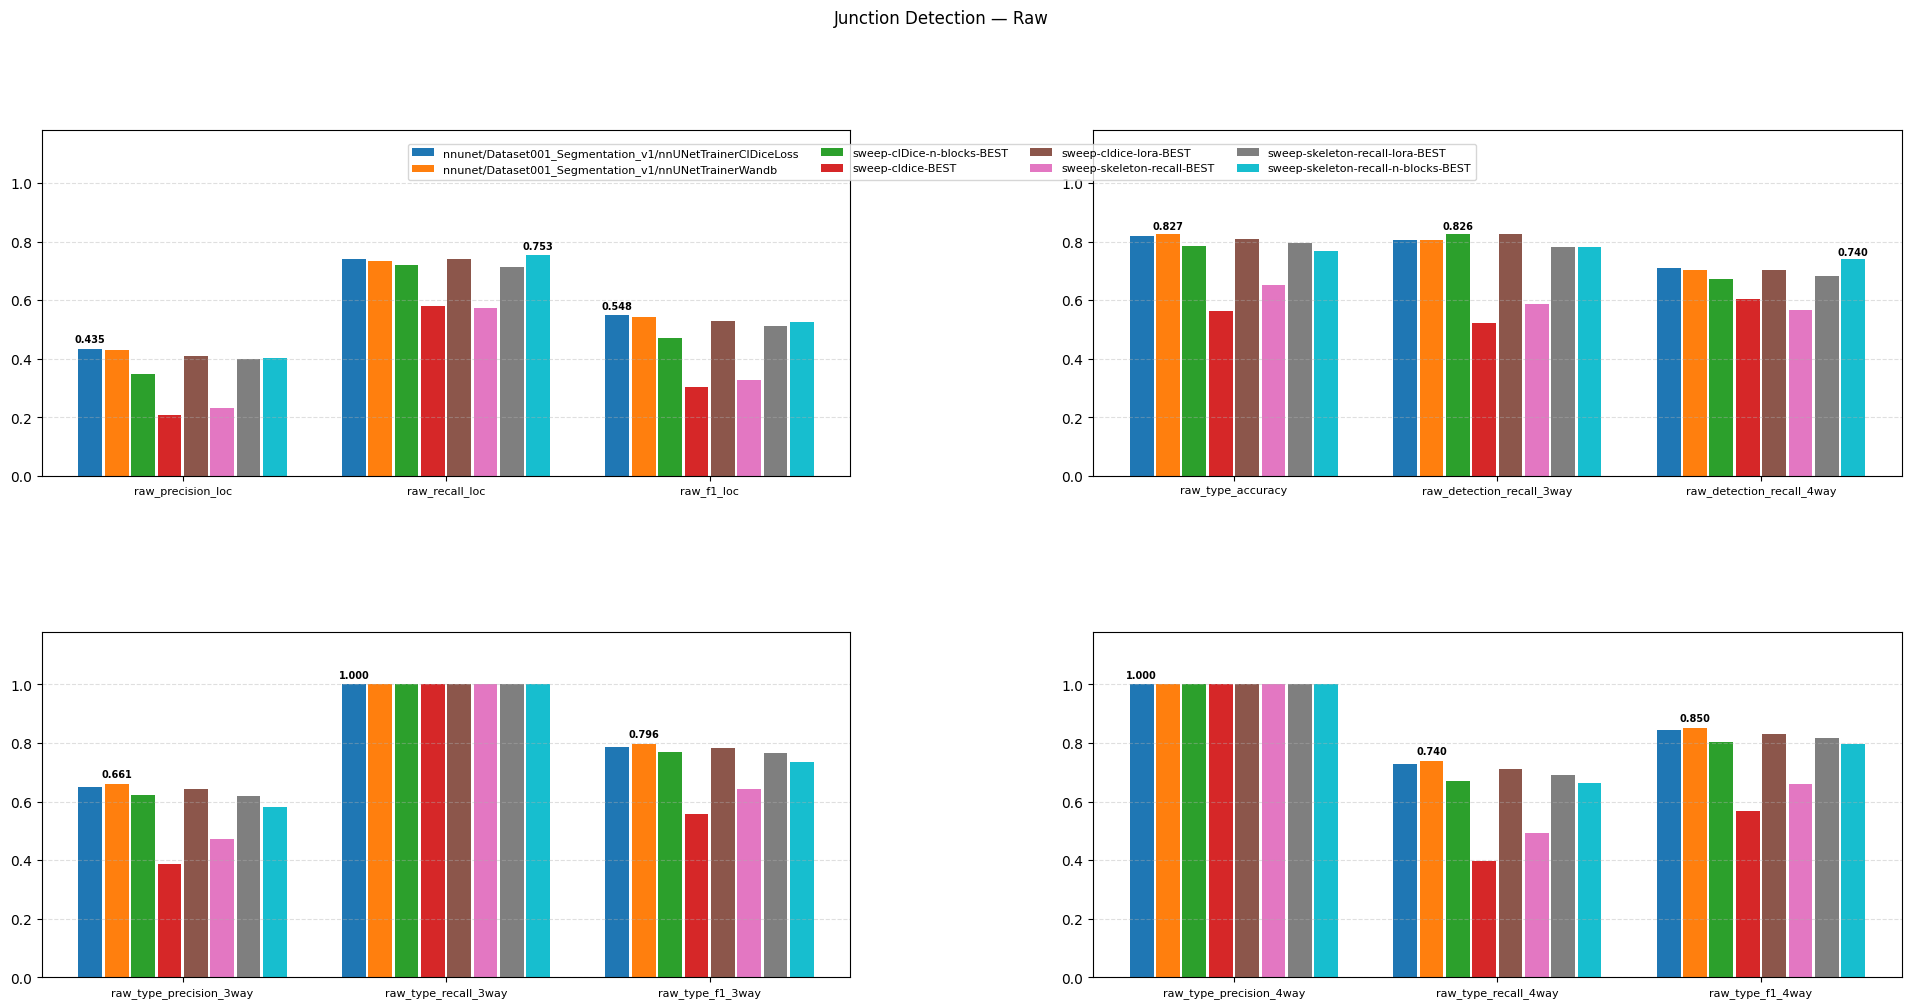

C:\Users\juhe9\AppData\Local\Temp\ipykernel_29064\2911670338.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, subplot_top])


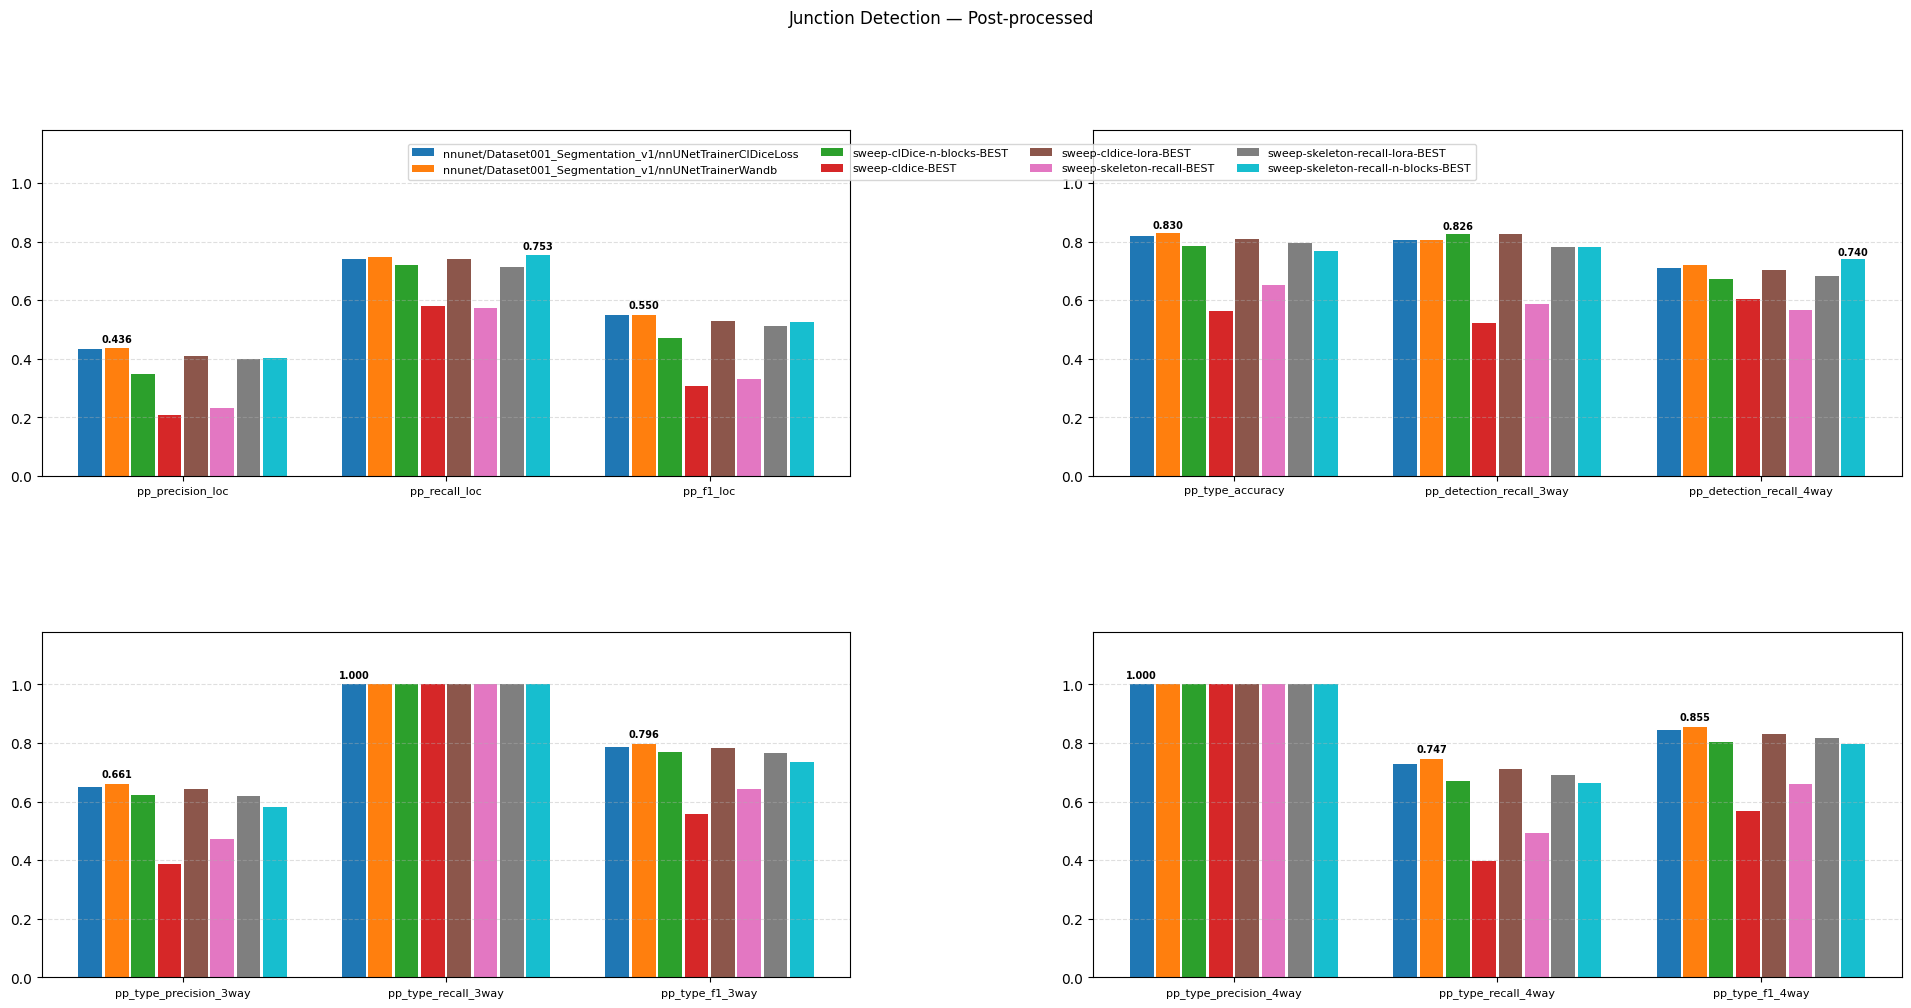

In [15]:
for _prefix, _label in [("raw_", "Raw"), ("pp_", "Post-processed")]:
    horizontal_bar_groups(
        df_jd,
        col_groups=[
            tuple(f"{_prefix}{c}" for c in _JD_LOCALISATION),
            tuple(f"{_prefix}{c}" for c in _JD_TYPE_OVERALL + _JD_DETECTION_RECALL),
            tuple(f"{_prefix}{c}" for c in _JD_TYPE_3WAY),
            tuple(f"{_prefix}{c}" for c in _JD_TYPE_4WAY),
        ],
        cols_per_row=2,
        suptitle=f"Junction Detection — {_label}",
    )

### Confusion Matrices

Displayed from the PNG files saved by `compute_metrics_junction_detection.py` (post-processed results).

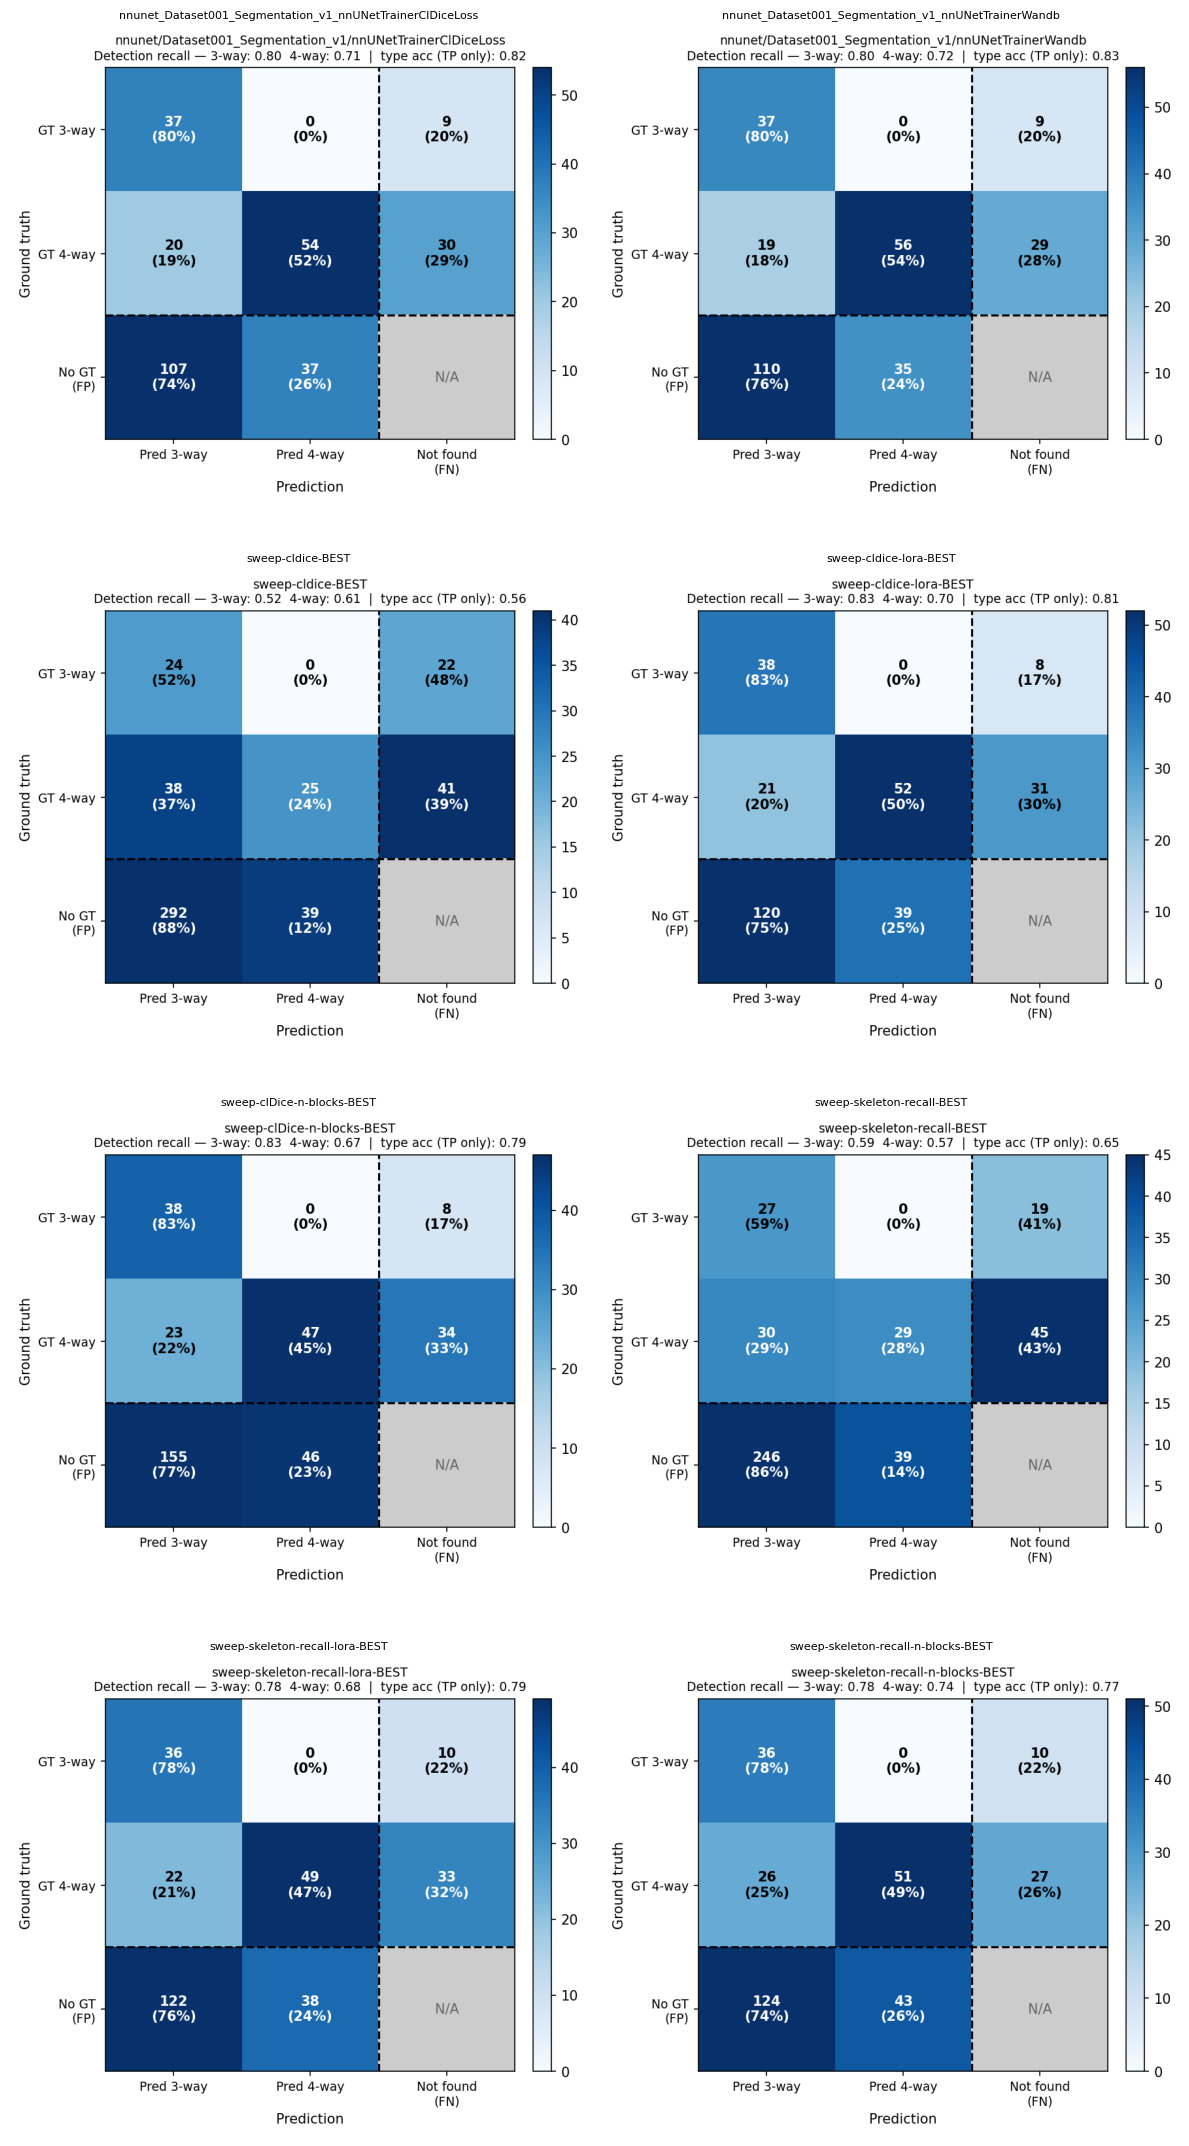

In [16]:
from PIL import Image as _PILImage

_cm_dir = JD_EVAL_DIR / "confusion_matrices"
_cm_pngs = sorted(_cm_dir.glob("cm_*.png")) if _cm_dir.is_dir() else []

if not _cm_pngs:
    print("No confusion-matrix PNGs found (run with --plot to generate them).")
else:
    n = len(_cm_pngs)
    _cols = 2
    _rows = (n + _cols - 1) // _cols
    fig, axes = plt.subplots(_rows, _cols, figsize=(6 * _cols, 5.5 * _rows))
    axes = np.array(axes).flatten()
    for ax, png in zip(axes, _cm_pngs):
        img = _PILImage.open(png)
        ax.imshow(np.array(img))
        ax.axis("off")
        ax.set_title(png.stem.removeprefix("cm_"), fontsize=8)
    # Hide any unused axes in the last row
    for ax in axes[n:]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()
    plt.close()

### Raw vs Post-processed: Key Metrics Side-by-side

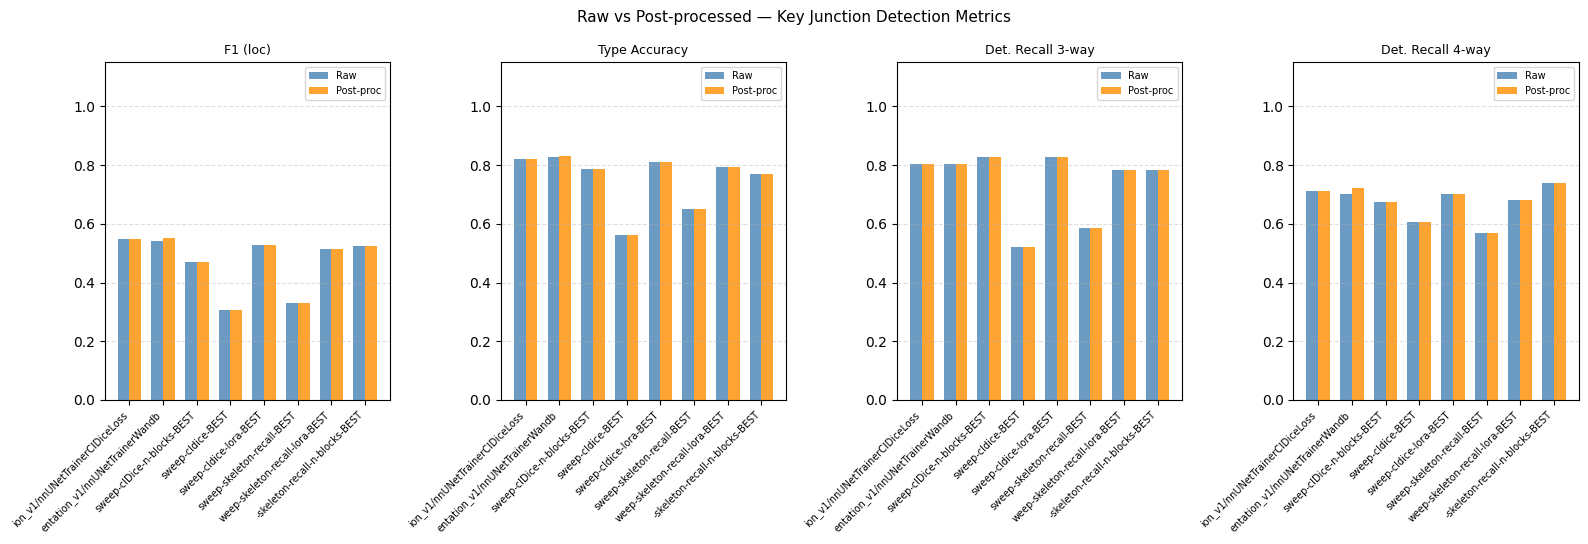

In [17]:
_KEY_METRICS = ["f1_loc", "type_accuracy", "detection_recall_3way", "detection_recall_4way"]
_short_labels = [str(n)[-30:] for n in df_jd.index]
colors = plt.cm.tab10(np.linspace(0, 0.9, len(df_jd)))

_present = [m for m in _KEY_METRICS
            if f"raw_{m}" in df_jd.columns and f"pp_{m}" in df_jd.columns]

if _present:
    fig, axes = plt.subplots(1, len(_present), figsize=(4 * len(_present), max(4, len(df_jd) * 0.5 + 1.5)),
                             squeeze=False)
    axes = axes[0]
    x = np.arange(len(df_jd))
    width = 0.35

    for ax, metric in zip(axes, _present):
        raw_vals = df_jd[f"raw_{metric}"].astype(float).values
        pp_vals  = df_jd[f"pp_{metric}"].astype(float).values
        ax.bar(x - width / 2, raw_vals, width, label="Raw", color="steelblue", alpha=0.8)
        ax.bar(x + width / 2, pp_vals,  width, label="Post-proc", color="darkorange", alpha=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(_short_labels, rotation=45, ha="right", fontsize=7)
        ax.set_ylim(0, 1.15)
        ax.set_title(_DISPLAY_RENAME.get(metric, metric), fontsize=9)
        ax.grid(axis="y", linestyle="--", alpha=0.4)
        ax.legend(fontsize=7)

    fig.suptitle("Raw vs Post-processed — Key Junction Detection Metrics", fontsize=11)
    plt.tight_layout()
    plt.show()
    plt.close()
else:
    print("Key metric columns not found in dataframe.")